# Torch-Keras profiling analysis

The benchmark reports large differences in training time between torch and torch-keras. This notebook analyses their profiling with nsys and answers two questions: Why is `torch-keras` the slowest backend? and why is its LSTM so extreme? In the published results it is 20-60x slower than the rest.

The answer to the first one is that at this batch size the GPU is idle most of the time in every backend: what is being compared is largely the per-operation cost of each abstraction layer. The answer to the second one is a Keras version: 3.8 unrolled the recurrent loop, while 3.15 dispatches to the fused cuDNN LSTM, which makes the same run 26x faster with identical losses.

## Data

| Source | What it holds |
|---|---|
| `data/published_epoch_times.csv` | Epoch times of the runs behind the paper (Keras 3.8 / torch 2.6 / TF 2.18 / JAX 0.4.30), summarized by `extract_published_times.py` from `results/final` at commit `cb012fd`, before the new re-runs |
| `data/profiling_new_env.log` | `nsys profile --stats` for `torch-keras` and `torch`, MLP and LSTM (Keras 3.15.1 / torch 2.10) |
| `data/profiling_old_env.log` | The same `torch-keras` LSTM run under Keras 3.8 / torch 2.6 and under Keras 3.15.1 / torch 2.10 |
| `data/profiling_epoch_times.csv` | Epoch times of those profiled runs |

Every profiled run uses the same GPU (one A100 80GB), fp32, seed 42, batch size 64 and 3 epochs.
Each log is the `--stats=true` output of `nsys profile --trace=cuda,cudnn,cublas,nvtx` around
`python experiment.py <backend> <model> simple fp32 --gpu-ids 2 --seed 42 --epochs 3`.
`nsys` adds CPU overhead, so absolute times are not comparable with the paper's: only the
comparisons between runs profiled the same way are.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import nsys_stats

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True})

BACKENDS = ["tf-keras", "torch-keras", "jax-keras", "torch", "jax"]
# Training batches per epoch, from the dataset sizes (Fashion-MNIST 48000, taxi windows 10368)
STEPS_PER_EPOCH = {"mlp": 750, "lstm": 162}
EPOCHS = 3

## 1. The time gap in the results

Median epoch time of the fp32 runs behind the paper, over the five seeds. The first epoch of each
run is dropped: it includes JIT compilation and warm-up.

In [2]:
published = pd.read_csv("data/published_epoch_times.csv")
published = published[published.precision == "fp32"]
published["model"] = published.model + " " + published.complexity

# Median over the five seeds of each run's median epoch time
published = (published.groupby(["model", "backend"]).median_epoch_time.median().unstack()[BACKENDS]
             .reindex(["mlp simple", "mlp complex", "cnn simple", "cnn complex", "lstm simple", "lstm complex"]))

published.round(2)

backend,tf-keras,torch-keras,jax-keras,torch,jax
model,,,,,
mlp simple,1.17,4.87,1.23,1.57,2.12
mlp complex,1.54,8.15,1.51,3.07,4.61
cnn simple,1.39,6.19,1.97,2.42,2.71
cnn complex,5.67,38.77,5.44,9.04,5.88
lstm simple,1.73,39.81,3.08,0.67,3.78
lstm complex,4.19,59.56,6.39,2.56,9.34


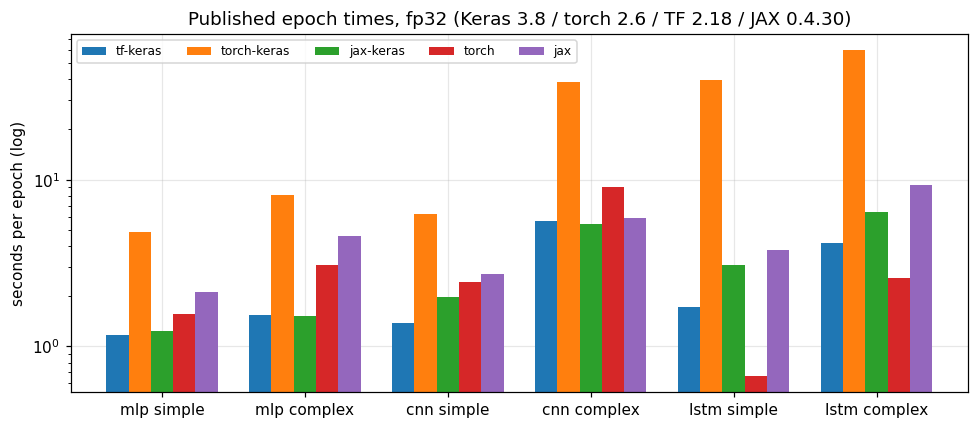

In [3]:
axis = published.plot.bar(figsize=(9, 4), logy=True, width=0.78)
axis.set_ylabel("seconds per epoch (log)")
axis.set_xlabel("")
axis.set_title("Published epoch times, fp32 (Keras 3.8 / torch 2.6 / TF 2.18 / JAX 0.4.30)")
axis.legend(ncols=5, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()

In [4]:
# How much slower torch-keras is than the median of the other four backends
others = published[[b for b in BACKENDS if b != "torch-keras"]].median(axis=1)

pd.DataFrame({"torch-keras": published["torch-keras"], "other backends (median)": others,
              "factor": published["torch-keras"] / others}).round(2)

,torch-keras,other backends (median),factor
model,,,
mlp simple,4.87,1.40,3.47
mlp complex,8.15,2.30,3.54
cnn simple,6.19,2.20,2.82
cnn complex,38.77,5.77,6.72
lstm simple,39.81,2.40,16.55
lstm complex,59.56,5.29,11.26


`torch-keras` is 2.8-6.7x slower on MLP and CNN, and 11-17x slower on LSTM. The penalty grows with the number of layers (3.5x on a 3-layer MLP, 6.7x on a 100-layer ResNet), which already suggests a per-operation cost rather than slow kernels. The LSTM is further analysed at section 3.

## 2. Profiling

`nsys` reports how long the GPU actually spent running kernels. Comparing that with the training
time separates GPU work from everything else (Python, dispatch, data loading).

In [5]:
epoch_times = pd.read_csv("data/profiling_epoch_times.csv")
profiled = epoch_times[epoch_times.comparison == "profiling"]
training_time = profiled.groupby(["backend", "model"]).epoch_time.sum()

rows = []
for name, section in nsys_stats.read_runs("data/profiling_new_env.log").items():
    backend, model = name.split()[:2]
    stats = nsys_stats.summary(section)
    rows.append({
        "backend": backend,
        "model": model,
        "training (s)": training_time[(backend, model)],
        "kernels (s)": stats["kernel_ms"] / 1000,
        "GPU busy (%)": 100 * stats["kernel_ms"] / 1000 / training_time[(backend, model)],
        "launches per epoch": stats["launches"] / EPOCHS,
        "launches per training step": stats["launches"] / EPOCHS / STEPS_PER_EPOCH[model],
        "host to device copies": stats["host_to_device_copies"],
    })

profile = pd.DataFrame(rows).set_index(["model", "backend"]).sort_index()
profile.round(1)

training (s)  kernels (s)  GPU busy (%)  \
model backend                                                
lstm  torch                 2.5          0.3          12.9   
      torch-keras           6.5          0.4           6.5   
mlp   torch                 6.2          0.6           8.9   
      torch-keras          18.6          1.1           5.8   

                   launches per epoch  launches per training step  \
model backend                                                       
lstm  torch                   13017.7                        80.4   
      torch-keras             26019.7                       160.6   
mlp   torch                   31649.0                        42.2   
      torch-keras             98491.0                       131.3   

                   host to device copies  
model backend                             
lstm  torch                         1354  
      torch-keras                   6013  
mlp   torch                         5948  
      torch-keras                  26863

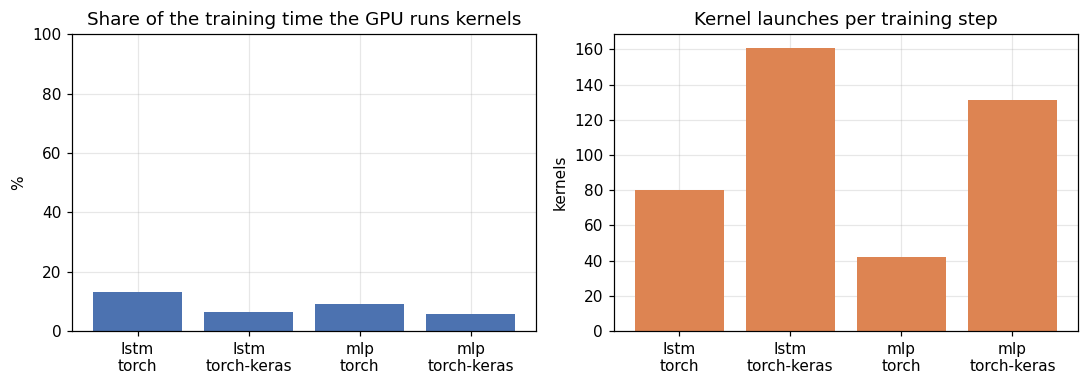

In [6]:
figure, (left, right) = plt.subplots(1, 2, figsize=(10, 3.6))
labels = [f"{model}\n{backend}" for model, backend in profile.index]

left.bar(labels, profile["GPU busy (%)"], color="#4c72b0")
left.set_title("Share of the training time the GPU runs kernels")
left.set_ylabel("%")
left.set_ylim(0, 100)

right.bar(labels, profile["launches per training step"], color="#dd8452")
right.set_title("Kernel launches per training step")
right.set_ylabel("kernels")

plt.tight_layout()

In all four runs the GPU runs kernels for less than 15% of the training time, so at batch size 64
these models are bound by the host, not by the device. `torch-keras` launches 2-3x more kernels than
the native loop for the same model and copies 4.5x more data from host to device on the MLP, and it
is 2-3x slower: the extra time is per-operation cost of the abstraction layer.

(The launches per step divide every launch, validation included, by the training steps, so they are
an upper bound; the ratio between backends is unaffected. `nsys` also inflates host time, which
makes the GPU busy share a lower bound.)

## 3. LSTM: same code, two Keras versions

The same run profiled twice on the same GPU, changing only the environment: Keras 3.8 with torch 2.6
(the versions behind the paper) and Keras 3.15.1 with torch 2.10.

In [7]:
versions = epoch_times[epoch_times.comparison == "versions"]
labels = {"torch_env": "Keras 3.8 / torch 2.6", "bm_torch_env": "Keras 3.15.1 / torch 2.10"}

rows = []
for name, section in nsys_stats.read_runs("data/profiling_old_env.log").items():
    environment = name.split()[-1]
    run = versions[versions.environment == environment]
    stats = nsys_stats.summary(section)
    kernels = nsys_stats.kernels(section)
    rows.append({
        "versions": labels[environment],
        "epoch time (s)": run.epoch_time.median(),
        "kernels (s)": stats["kernel_ms"] / 1000,
        "launches": stats["launches"],
        "fused cuDNN LSTM kernels": kernels.kernel.str.contains("RNN_blockPersist|cudnnRNN").sum(),
        "last val_loss": run.val_loss.iloc[-1],
    })

comparison = pd.DataFrame(rows).set_index("versions")
comparison.round({"epoch time (s)": 2, "kernels (s)": 2, "last val_loss": 6})

,epoch time (s),kernels (s),launches,fused cuDNN LSTM kernels,last val_loss
versions,,,,,
Keras 3.8 / torch 2.6,54.74,15.79,5513333,0,0.012006
Keras 3.15.1 / torch 2.10,2.10,0.42,78059,3,0.012006


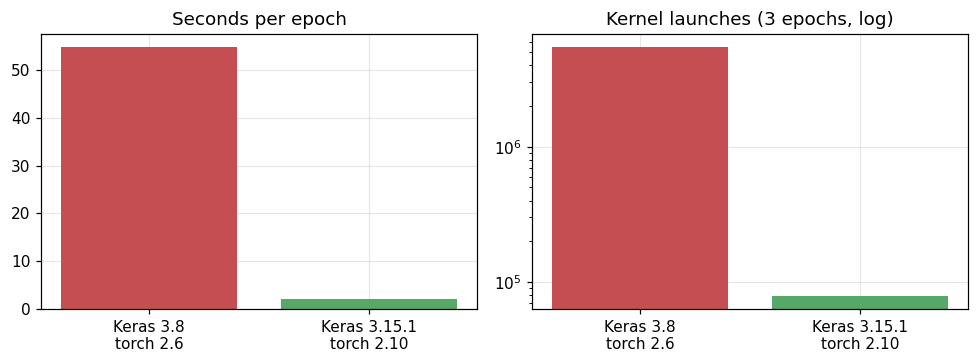

In [8]:
figure, (left, right) = plt.subplots(1, 2, figsize=(9, 3.4))
colors = ["#c44e52", "#55a868"]

left.bar(comparison.index, comparison["epoch time (s)"], color=colors)
left.set_title("Seconds per epoch")
left.set_xticks(range(2), ["Keras 3.8\ntorch 2.6", "Keras 3.15.1\ntorch 2.10"])

right.bar(comparison.index, comparison["launches"], color=colors, log=True)
right.set_title("Kernel launches (3 epochs, log)")
right.set_xticks(range(2), ["Keras 3.8\ntorch 2.6", "Keras 3.15.1\ntorch 2.10"])

plt.tight_layout()

In [9]:
# The four kernels that dominate each version
for name, section in nsys_stats.read_runs("data/profiling_old_env.log").items():
    top = nsys_stats.kernels(section).nlargest(4, "ms")
    top["kernel"] = top.kernel.str.replace(r"^void |<.*", "", regex=True).str.slice(0, 48)
    print(labels[name.split()[-1]])
    print(top.to_string(index=False, float_format="%.1f"), "\n")

Keras 3.8 / torch 2.6
                                   kernel     ms  launches
at::native::vectorized_elementwise_kernel 2740.1   1423277
at::native::vectorized_elementwise_kernel 1823.6    949190
                   ampere_sgemm_128x32_nn 1820.2    389180
           at::native::elementwise_kernel 1772.3    583770 

Keras 3.15.1 / torch 2.10
                        kernel   ms  launches
      RNN_blockPersist_fp_LSTM 78.2      1342
  RNN_blockPersist_bp_LSTM_FMA 75.7       972
       GENERIC_elementWise_bp2 50.7       972
at::native::elementwise_kernel 23.9      7733 



Keras 3.8 runs no fused cuDNN LSTM kernel: it unrolls the time steps into elementwise operations and small GEMMs (general matrix multiplications), which is why it launches 5.5 million kernels in three epochs. Keras 3.15.1 calls the same fused `RNN_blockPersist_*` kernels that the native torch loop uses, and needs 78 thousand launches. The losses of the two runs match to the sixth decimal, so the computation is the same: only its execution changed.

## Takeaways

- At batch size 64, these workloads are host-bound: the GPU runs kernels less than 15% of the time. Time differences between backends mostly measure per-operation cost, not kernel speed. Larger batches would shift the balance.
- The general penalty of `torch-keras` (2.8-6.7x) comes from launching 2-3x more kernels per step and moving more data per step than the native loop. It grows with the number of layers.
- The LSTM figures published for `torch-keras` measure a limitation of Keras 3.8, fixed upstream: the same code is 26x faster on Keras 3.15.1, with identical losses.